## PHYS-467 Machine Learning for Physicists — Exercise session 5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from urllib.request import urlopen
from tqdm.auto import tqdm

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, RidgeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

np.random.seed(42)

**Note**. Some of the functions imported above will be useful, and in a few cases explicitly required, in the exercises below.

# Exercise 1: (Stochastic) Gradient Descent with Logistic Regression

**Question 1.a)** Implement the sigmoid function $\sigma(x)=1/(1+e^{-x})$.

In [2]:
def sigmoid(x):
    # Numerically stable expression for the sigmoid.
    return np.exp(-np.logaddexp(0, -np.asarray(x)))

**Question 1.b)** Generate a random $n\times d$ Gaussian data matrix with $n=100$, $d=2$ and a random teacher vector $w_\star$. Generate labels $y\in\{-1,+1\}$ with

$$\mathbb P(y=1\mid x)=\sigma(w_\star^\top x).$$

*Hint:* `y = 2 * np.random.binomial(1, sigmoid(X @ w_opt)) - 1`.

In [3]:
n, d = 100, 2
w_opt = np.random.randn(d)
X = np.random.randn(n, d)
y = 2 * np.random.binomial(1, sigmoid(X @ w_opt)) - 1

**Question 1.c)** Verify numerically that $\sigma(x)=1-\sigma(-x)$.

In [4]:
print(sigmoid(X[1]))
print(1 - sigmoid(-X[1]))
print('Identity holds:', np.allclose(sigmoid(X[1]), 1 - sigmoid(-X[1])))

[0.44172766 0.44173171]
[0.44172766 0.44173171]
Identity holds: True


**Question 1.d)** Implement one gradient-descent step for logistic regression, and a function applying multiple steps. For labels $y_i\in\{-1,+1\}$, consider the **summed** logistic loss

$$\mathcal L(w)=\sum_{i=1}^n \log(1+e^{-y_i x_i^\top w}),\qquad
\nabla_w\mathcal L = X^\top\bigl[(\sigma(y\odot Xw)-1)\odot y\bigr].$$

The multi-step function should return the weight vector **after each update**.

In [5]:
def gradient_step_logistic(X, y, w_, lr=0.01):
    gradient = X.T @ ((sigmoid(y * (X @ w_)) - 1) * y)
    return w_ - lr * gradient

def gradient_descent_logistic(X, y, w_init, lr=0.01, n_iter=100):
    w = w_init.copy()
    ws = []
    for _ in range(n_iter):
        w = gradient_step_logistic(X, y, w, lr)
        ws.append(w.copy())
    return np.asarray(ws)

**Question 1.e)** Implement stochastic gradient descent (SGD) by using the same step function on a random mini-batch of 10 observations at every iteration. Sample the mini-batch indices with replacement.

In [6]:
def stochastic_gradient_descent_logistic(X, y, w_init, lr=0.01, n_iter=100):
    w = w_init.copy()
    ws = []
    batch_size = 10
    for _ in range(n_iter):
        indices = np.random.randint(0, X.shape[0], size=batch_size)
        w = gradient_step_logistic(X[indices], y[indices], w, lr)
        ws.append(w.copy())
    return np.asarray(ws)

**Question 1.f)** Compare GD and mini-batch SGD with the same *sample-gradient budget*. Start both at $w_0=0$ with $\eta=10^{-2}$ and use $100$ **effective epochs**. One GD update evaluates the gradient on all $n=100$ examples, whereas one SGD update uses a mini-batch of $b=10$ examples (sampled **with replacement**). Thus,

$$\text{effective epochs}_{\rm GD}=k,\qquad
\text{effective epochs}_{\rm SGD}=\frac{bk}{n},$$

where $k$ denotes the number of updates. Run $100$ GD updates and $1000$ SGD updates. This equalizes the total number of examples used to evaluate gradients, **not** wall-clock time or the number of parameter updates. Since SGD samples with replacement, an effective epoch does not mean that every training example has been visited once.

Plot **both** (i) the cosine similarity with the teacher,

$$\cos(w_t,w_\star)=\frac{w_t^\top w_\star}{\|w_t\|_2\,\|w_\star\|_2},$$

and (ii) the **mean training logistic loss** against effective epochs. What differs between the GD and SGD trajectories? Does a smaller training loss necessarily mean that the weights are closer in direction to the teacher?

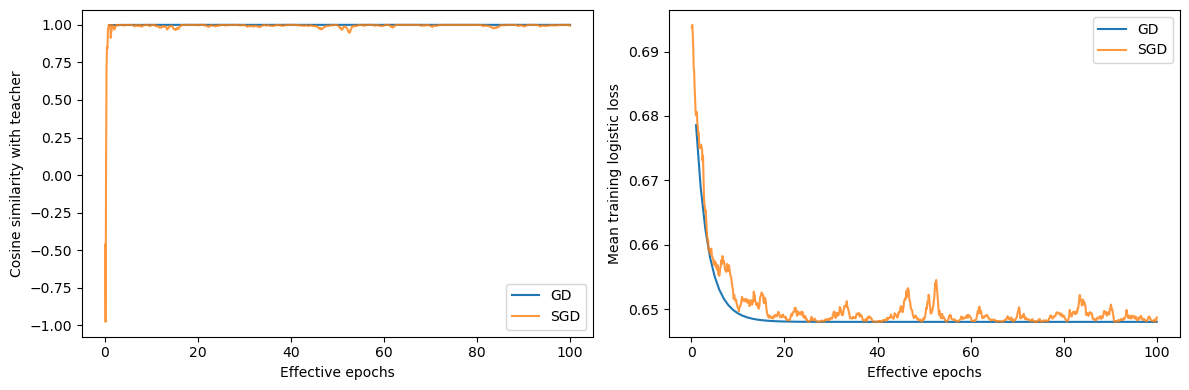

In [7]:
n_epochs = 100
batch_size = 10  # Matches the mini-batch size in stochastic_gradient_descent_logistic.

# The two runs use the same total number of sample-gradient evaluations.
ws_gd = gradient_descent_logistic(X, y, np.zeros(d), lr=1e-2, n_iter=n_epochs)
ws_sgd = stochastic_gradient_descent_logistic(
    X, y, np.zeros(d), lr=1e-2, n_iter=n_epochs * n // batch_size
)

gd_epochs = np.arange(1, len(ws_gd) + 1)
sgd_epochs = np.arange(1, len(ws_sgd) + 1) * batch_size / n

# The mean loss is used for plotting; the update functions still use summed gradients.
def mean_logistic_loss(X, y, w):
    return np.mean(np.logaddexp(0, -y * (X @ w)))

cos_gd = ws_gd @ w_opt / (np.linalg.norm(ws_gd, axis=1) * np.linalg.norm(w_opt))
cos_sgd = ws_sgd @ w_opt / (np.linalg.norm(ws_sgd, axis=1) * np.linalg.norm(w_opt))

loss_gd = np.array([mean_logistic_loss(X, y, w) for w in ws_gd])
loss_sgd = np.array([mean_logistic_loss(X, y, w) for w in ws_sgd])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(gd_epochs, cos_gd, label='GD')
axes[0].plot(sgd_epochs, cos_sgd, label='SGD', alpha=0.8)
axes[0].set_xlabel('Effective epochs')
axes[0].set_ylabel('Cosine similarity with teacher')
axes[0].legend()

axes[1].plot(gd_epochs, loss_gd, label='GD')
axes[1].plot(sgd_epochs, loss_sgd, label='SGD', alpha=0.8)
axes[1].set_xlabel('Effective epochs')
axes[1].set_ylabel('Mean training logistic loss')
axes[1].legend()

fig.tight_layout()
plt.show()

**Question 1.g)** Fit scikit-learn's `LogisticRegression` with `fit_intercept=False` and **no penalty**, so that it optimizes the same unregularized objective as GD and SGD. Compare the **training accuracies** of scikit-learn, GD, SGD, and the teacher classifier.

In [8]:
logistic_regression = LogisticRegression(fit_intercept=False, penalty=None, max_iter=2000)
logistic_regression.fit(X, y)

def binary_accuracy(w):
    return np.mean(np.where(X @ w >= 0, 1, -1) == y)

print('scikit-learn:', accuracy_score(y, logistic_regression.predict(X)))
print('GD:         ', binary_accuracy(ws_gd[-1]))
print('SGD:        ', binary_accuracy(ws_sgd[-1]))
print('Teacher:    ', binary_accuracy(w_opt))

scikit-learn: 0.62
GD:          0.62
SGD:         0.6
Teacher:     0.62


**Question 1.h)** Investigate the role of the learning rate: run GD on the same data with the much larger step size $\eta=10$. Plot the *mean* logistic loss versus iteration, and compare with $\eta=10^{-2}$. Does the larger step size converge?

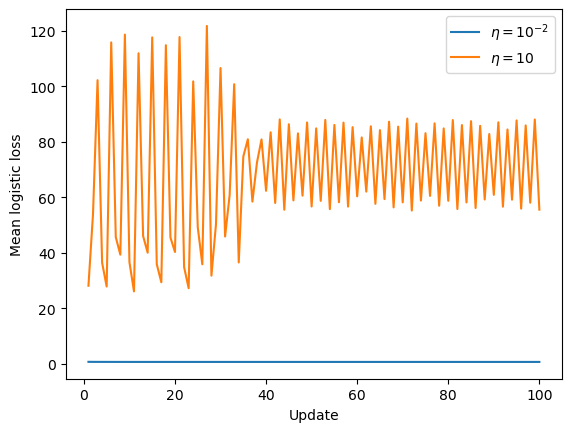

In [9]:
ws_large_lr = gradient_descent_logistic(X, y, np.zeros(d), lr=10.0, n_iter=100)
loss_large = [mean_logistic_loss(X, y, w) for w in ws_large_lr]
loss_small = [mean_logistic_loss(X, y, w) for w in ws_gd[:100]]
plt.plot(np.arange(1, 101), loss_small, label=r'$\eta=10^{-2}$')
plt.plot(np.arange(1, 101), loss_large, label=r'$\eta=10$')
plt.xlabel('Update')
plt.ylabel('Mean logistic loss')
plt.legend()
plt.show()

**Question 1.i) — Early stopping.** For a small training set with noisy labels, minimizing training loss for too long may hurt generalization. The following cell prepares training/validation data and runs GD. Plot both losses, identify the update with the smallest validation loss, and explain why one might stop there **without using the validation set to update the weights**.

The labels used for training have an extra 10% of randomly flipped signs; the validation set has no such additional flips.

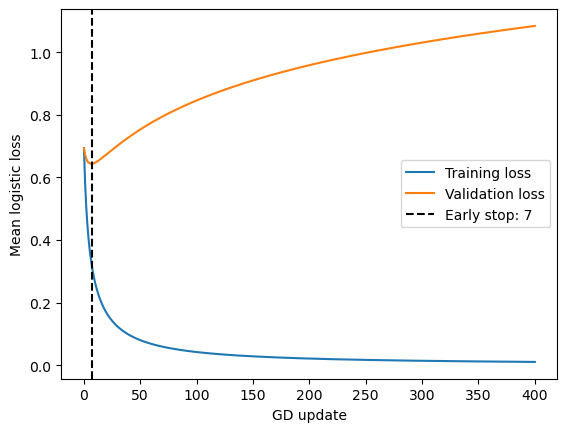

Validation loss at best update: 0.644; at last update: 1.084


In [10]:
rng_es = np.random.default_rng(2026)
n_es, d_es = 60, 100
w_teacher_es = 0.25 * rng_es.standard_normal(d_es)
X_es = rng_es.standard_normal((n_es, d_es))
X_val_es = rng_es.standard_normal((1000, d_es))
y_es = 2 * rng_es.binomial(1, sigmoid(X_es @ w_teacher_es)) - 1
y_val_es = 2 * rng_es.binomial(1, sigmoid(X_val_es @ w_teacher_es)) - 1
y_es[rng_es.random(n_es) < 0.10] *= -1

w_path_es = np.vstack([np.zeros(d_es), gradient_descent_logistic(
    X_es, y_es, np.zeros(d_es), lr=0.004, n_iter=400)])
# Each column gives the scores at one update; np.logaddexp computes the logistic loss stably.
train_loss_es = np.logaddexp(0, -y_es[:, None] * (X_es @ w_path_es.T)).mean(axis=0)
val_loss_es = np.logaddexp(0, -y_val_es[:, None] * (X_val_es @ w_path_es.T)).mean(axis=0)
best_iter_es = int(np.argmin(val_loss_es))

plt.plot(train_loss_es, label='Training loss')
plt.plot(val_loss_es, label='Validation loss')
plt.axvline(best_iter_es, linestyle='--', color='k', label=f'Early stop: {best_iter_es}')
plt.xlabel('GD update')
plt.ylabel('Mean logistic loss')
plt.legend()
plt.show()
print(f'Validation loss at best update: {val_loss_es[best_iter_es]:.3f}; at last update: {val_loss_es[-1]:.3f}')

*Solution note:* The training loss decreases almost to zero, whereas the validation loss reaches a minimum after a few updates and then increases. Choosing the minimum-validation-loss iterate is **early stopping**: it limits overfitting without modifying the update rule. The validation data are used only to select the stopping time, never to compute a gradient.

# Exercise 2: LASSO

**Question 2.a)** Generate independent Gaussian training and testing design matrices $X_{\mathrm{train}}$ and $X_{\mathrm{test}}$, both with $n=300$ samples and $d=10$ features. Use independent standard normal entries.

In [11]:
rng_lasso = np.random.default_rng(42)
n, d = 300, 10
X_train = rng_lasso.standard_normal((n, d))
X_test = rng_lasso.standard_normal((n, d))

**Question 2.b)** Use the sparse teacher $w_\star$ generated below. Print it, and generate **both training and testing labels**, with independent unit-variance Gaussian observation noise: $y=Xw_\star+\xi$.

In [12]:
w_opt = rng_lasso.choice([0, 1, -1], d, p=[0.7, 0.15, 0.15])
print('Teacher:', w_opt)
y_train = X_train @ w_opt + rng_lasso.standard_normal(n)
y_test = X_test @ w_opt + rng_lasso.standard_normal(n)

Teacher: [ 0  1  0 -1  1  1  1  0  0  0]


**Question 2.c)** Fit ordinary least squares without an intercept. Print the fitted coefficients and training mean squared error.

In [13]:
linear_regression = LinearRegression(fit_intercept=False)
linear_regression.fit(X_train, y_train)
print('OLS coefficients:', linear_regression.coef_)
print('Training MSE:', np.mean((linear_regression.predict(X_train) - y_train)**2))

OLS coefficients: [-0.08848901  1.02099112  0.02184749 -1.02333366  0.99307305  1.00733228
  1.01905859 -0.10466465 -0.02642352 -0.01622355]
Training MSE: 1.075730043447909


**Question 2.d)** Fit scikit-learn's LASSO without an intercept using `alpha=0.1`. Print its coefficients and training mean squared error. What do you notice about the coefficients compared with OLS? (scikit-learn calls the penalty strength `alpha`.)

In [14]:
lasso = Lasso(fit_intercept=False, alpha=0.1)
lasso.fit(X_train, y_train)
print('LASSO coefficients:', lasso.coef_)
print('Training MSE:', np.mean((lasso.predict(X_train) - y_train)**2))

LASSO coefficients: [-0.          0.9113228   0.         -0.93534014  0.89280212  0.93626907
  0.9601745  -0.00726711 -0.         -0.        ]
Training MSE: 1.1360345586063765


**Question 2.e)** Use **5-fold cross-validation on the training data** to select the LASSO regularization strength $\lambda>0$. Plot the mean validation MSE and the fitted coefficients versus $\lambda$. Finally, fit at the selected $\lambda$ and evaluate once on the independent test set.

*Hint:* `cross_val_score` returns negative MSE for `scoring='neg_mean_squared_error'`. Do **not** use test data to select $\lambda$.

Best lambda (5-fold CV): 0.02807
Final coefficients: [-0.05555     0.98936727  0.         -0.99829561  0.96284128  0.98747701
  1.00401714 -0.07640137 -0.         -0.        ]
Teacher coefficients: [ 0  1  0 -1  1  1  1  0  0  0]
Held-out test MSE: 1.013776027168427


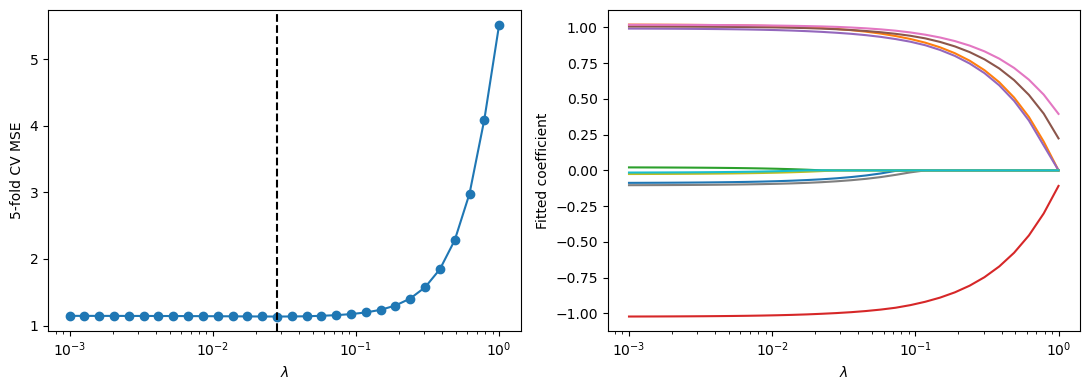

In [15]:
lambdas = np.logspace(-3, 0, 30)  # strictly positive
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_errors = []
ws_lasso = []
for lam in lambdas:
    model = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='neg_mean_squared_error')
    cv_errors.append(-scores.mean())
    model.fit(X_train, y_train)
    ws_lasso.append(model.coef_.copy())
cv_errors = np.asarray(cv_errors)
ws_lasso = np.asarray(ws_lasso)

best_lambda = lambdas[np.argmin(cv_errors)]
final_lasso = Lasso(alpha=best_lambda, fit_intercept=False, max_iter=10000).fit(X_train, y_train)
print(f'Best lambda (5-fold CV): {best_lambda:.4g}')
print('Final coefficients:', final_lasso.coef_)
print('Teacher coefficients:', w_opt)
print('Held-out test MSE:', np.mean((final_lasso.predict(X_test) - y_test)**2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(lambdas, cv_errors, marker='o')
axes[0].axvline(best_lambda, color='k', linestyle='--')
axes[0].set(xlabel=r'$\lambda$', ylabel='5-fold CV MSE')
axes[1].semilogx(lambdas, ws_lasso)
axes[1].set(xlabel=r'$\lambda$', ylabel='Fitted coefficient')
plt.tight_layout()
plt.show()

# Exercise 3: Ridge Classification and Logistic Regression

In this exercise we compare linear classifiers on a synthetic two-dimensional dataset.

**Question 3.a)** Use `make_classification` to generate 1000 samples in two dimensions, with `n_informative=2`, `n_redundant=0`, `n_clusters_per_class=1`, and `random_state=12`. Split them into 80% training and 20% testing using `random_state=42`.

In [16]:
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=12)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Question 3.b)** Scatter-plot the **training set**, coloring the points by **class label** (`c=y_train`).

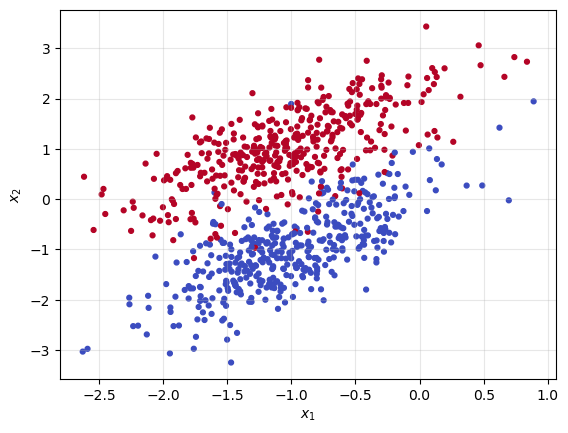

In [17]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=12)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(alpha=0.3)
plt.show()

**Question 3.c)** Train a ridge classifier and logistic regression using scikit-learn. Compare their test accuracies. Set `alpha=1` for ridge classification (this is also the scikit-learn default).

In [18]:
ridge_classifier = RidgeClassifier(alpha=1.0).fit(X_train, y_train)
logistic_regression = LogisticRegression().fit(X_train, y_train)
accuracy_ridge = accuracy_score(y_test, ridge_classifier.predict(X_test))
accuracy_logistic = accuracy_score(y_test, logistic_regression.predict(X_test))
print('Ridge test accuracy:', accuracy_ridge)
print('Logistic test accuracy:', accuracy_logistic)

Ridge test accuracy: 0.955
Logistic test accuracy: 0.97


**Question 3.d)** Plot the decision boundaries using the function supplied below. For logistic regression, the decision boundary is the contour of class-1 probability equal to 0.5.

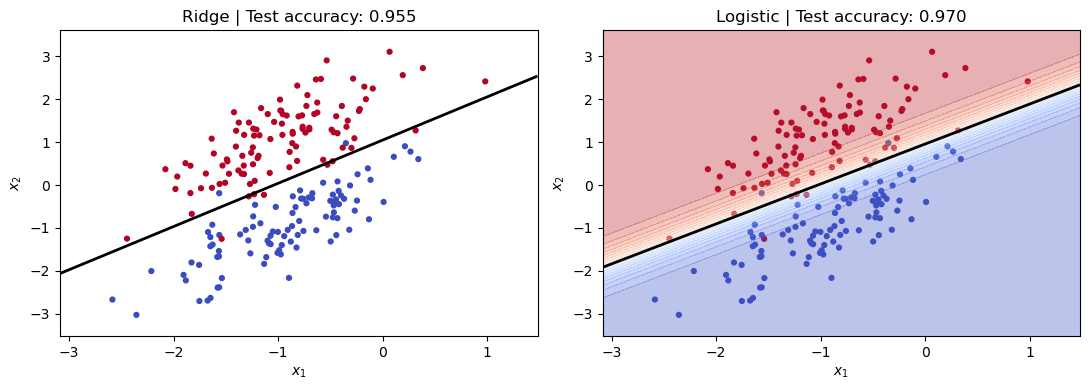

In [19]:
def plot_decision_boundaries(X_test, y_test, ridge_classifier, logistic_regression,
                             accuracy_ridge, accuracy_logistic):
    x0 = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 100)
    x1 = np.linspace(X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5, 100)
    xx, yy = np.meshgrid(x0, x1)
    grid = np.c_[xx.ravel(), yy.ravel()]
    z_ridge = ridge_classifier.decision_function(grid).reshape(xx.shape)
    z_logistic = logistic_regression.predict_proba(grid)[:, 1].reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, title, score in zip(axes, ['Ridge', 'Logistic'], [accuracy_ridge, accuracy_logistic]):
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=12)
        ax.set_title(f'{title} | Test accuracy: {score:.3f}')
        ax.set(xlabel=r'$x_1$', ylabel=r'$x_2$')
    axes[0].contour(xx, yy, z_ridge, levels=[0], colors='k', linewidths=2)
    axes[1].contourf(xx, yy, z_logistic, levels=np.linspace(0, 1, 21), cmap='coolwarm', alpha=0.35)
    axes[1].contour(xx, yy, z_logistic, levels=[0.5], colors='k', linewidths=2)
    plt.tight_layout()
    plt.show()

plot_decision_boundaries(X_test, y_test, ridge_classifier, logistic_regression,
                         accuracy_ridge, accuracy_logistic)

**Question 3.e)** Implement ridge classification from scratch. For this question, the target labels are $\{-1,+1\}$ and predictions use the sign of the linear score. Include an intercept **but do not penalize it**, to match `RidgeClassifier(fit_intercept=True)`. For the augmented design matrix $\widetilde X=[X\ \mathbf 1]$, use

$$\widehat\theta=(\widetilde X^\top\widetilde X+\alpha\,\mathrm{diag}(1,\ldots,1,0))^{-1}\widetilde X^\top y.$$

Implement one training function and one prediction function.

In [20]:
def ridge_classifier_train(X, y_signed, alpha=1.0):
    n_samples, n_features = X.shape
    X_augmented = np.column_stack((X, np.ones(n_samples)))
    penalty = np.diag([1.0] * n_features + [0.0])  # intercept unpenalized
    theta = np.linalg.solve(X_augmented.T @ X_augmented + alpha * penalty,
                            X_augmented.T @ y_signed)
    return theta[:-1], theta[-1]

def ridge_classifier_predict(X, coef_, intercept_):
    scores = X @ coef_ + intercept_
    return np.where(scores >= 0, 1, -1)

**Question 3.f)** With `alpha=1`, plot the **custom classifier's** decision boundary alongside scikit-learn's boundary. Compare the coefficients, intercept, and test accuracy.

Custom test accuracy: 0.955
Custom weights/intercept: [-0.76083192  0.75497642] -0.7907537438455056
sklearn weights/intercept: [-0.76083192  0.75497642] [-0.79075374]


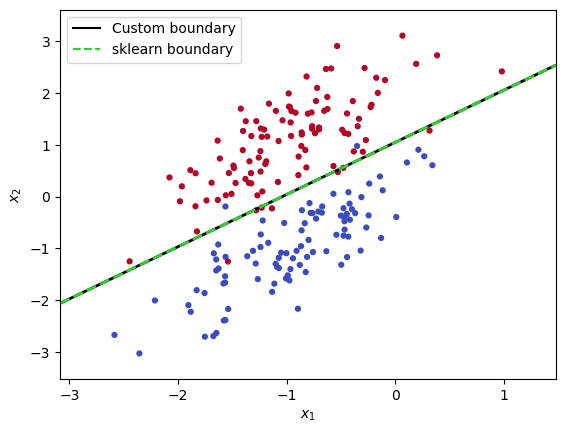

In [21]:
y_train_signed = 2 * y_train - 1
y_test_signed = 2 * y_test - 1
coef_, intercept_ = ridge_classifier_train(X_train, y_train_signed, alpha=1.0)
y_pred_custom = ridge_classifier_predict(X_test, coef_, intercept_)
print('Custom test accuracy:', accuracy_score(y_test_signed, y_pred_custom))
print('Custom weights/intercept:', coef_, intercept_)
print('sklearn weights/intercept:', np.ravel(ridge_classifier.coef_), np.ravel(ridge_classifier.intercept_))

x0 = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 100)
x1 = np.linspace(X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5, 100)
xx, yy = np.meshgrid(x0, x1)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_custom = (grid @ coef_ + intercept_).reshape(xx.shape)
Z_sklearn = ridge_classifier.decision_function(grid).reshape(xx.shape)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=12)
plt.contour(xx, yy, Z_custom, levels=[0], colors='k', linewidths=2)
plt.contour(xx, yy, Z_sklearn, levels=[0], colors='limegreen', linestyles='--', linewidths=2)
plt.plot([], [], color='k', label='Custom boundary')
plt.plot([], [], color='limegreen', linestyle='--', label='sklearn boundary')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.legend()
plt.show()

# Exercise 4: Classification of Ising-model configurations

We apply linear classifiers to predict the ordered/disordered phase of the two-dimensional ferromagnetic Ising model. Under the convention $H=-J\sum_{\langle i,j\rangle}s_i s_j$, the coupling is $J>0$ and $T_c=2J/\log(1+\sqrt{2})\approx2.269J$ in the thermodynamic limit. This dataset uses $L=40$ and temperatures in units of $J=1$.

**Note:** Spin-flip symmetry means that an order parameter such as $|m|$ or $m^2$ is a more natural phase indicator than a generic linear function of raw spins. Keep that limitation in mind when interpreting the accuracies.

In [22]:
L = 40
J = 1.0
T_c = 2 * J / np.log(1 + np.sqrt(2))
print(f'Thermodynamic critical temperature: {T_c:.4f}')

Thermodynamic critical temperature: 2.2692


**Question 4.a)** Load the data using the supplied function. The first **70,000** configurations are ordered, the next **30,000** are near-critical, and the last **60,000** are disordered. Concatenate the ordered/disordered configurations and split them equally into training and validation sets. Keep the near-critical configurations separate to evaluate extrapolation toward criticality.

*Note:* This cell downloads a large trusted teaching dataset from Boston University; it requires an internet connection and may use substantial memory. Do not execute untrusted pickle files.

In [23]:
def load_data():
    url_main = 'https://physics.bu.edu/~pankajm/ML-Review-Datasets/isingMC/'
    data_file_name = 'Ising2DFM_reSample_L40_T=All.pkl'
    label_file_name = 'Ising2DFM_reSample_L40_T=All_labels.pkl'
    packed = pickle.load(urlopen(url_main + data_file_name))
    data = np.unpackbits(packed).reshape(-1, L * L).astype(np.int8)
    data[data == 0] = -1
    labels = np.asarray(pickle.load(urlopen(url_main + label_file_name)))
    return data, labels

# The three temperature regions are arranged sequentially in these files.
data, labels = load_data()
X_ordered, Y_ordered = data[:70000], labels[:70000]
X_critical, Y_critical = data[70000:100000], labels[70000:100000]
X_disordered, Y_disordered = data[100000:], labels[100000:]
X_noncritical = np.concatenate([X_ordered, X_disordered])
Y_noncritical = np.concatenate([Y_ordered, Y_disordered])
X_train, X_val, Y_train, Y_val = train_test_split(
    X_noncritical, Y_noncritical, train_size=0.5, random_state=42, stratify=Y_noncritical)
print('Training:', X_train.shape, 'Validation:', X_val.shape,
      'Near critical:', X_critical.shape)

Training: (65000, 1600) Validation: (65000, 1600) Near critical: (30000, 1600)


**Question 4.b)** Display one example configuration from each **temperature regime**: ordered, near-critical and disordered. The plotting code is supplied.

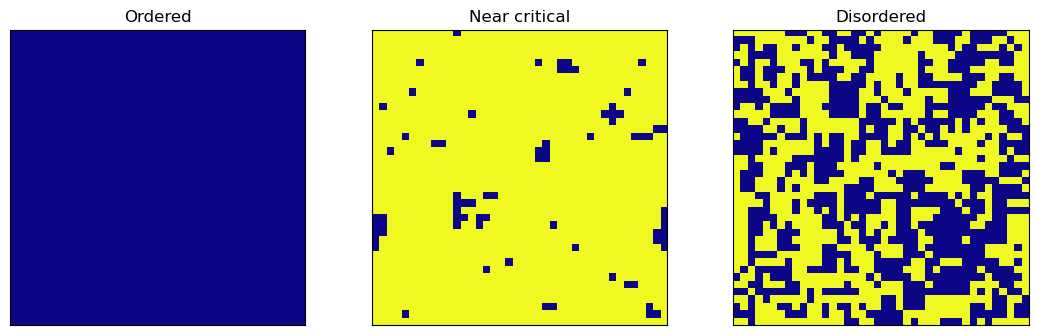

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, sample, title in zip(
    axes,
    [X_ordered[20001], X_critical[1000], X_disordered[50000]],
    ['Ordered', 'Near critical', 'Disordered']):
    ax.imshow(sample.reshape(L, L), cmap='plasma_r', vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

**Question 4.c)** Fit ridge and logistic classifiers at several regularization strengths. Plot **training, validation and near-critical classification accuracies** and interpret the difference between validation and near-critical performance. Accuracy may depend only weakly on regularization in this setting.

We use `alpha` for ridge regularization and `C=1/alpha` for logistic regression. The conventions/scales of these two penalty parameters **are not directly comparable**. Training on the full Ising dataset can take some time. Accuracy is a number in $[0,1]$, so use a linear vertical axis.

  0%|          | 0/9 [00:00<?, ?it/s]

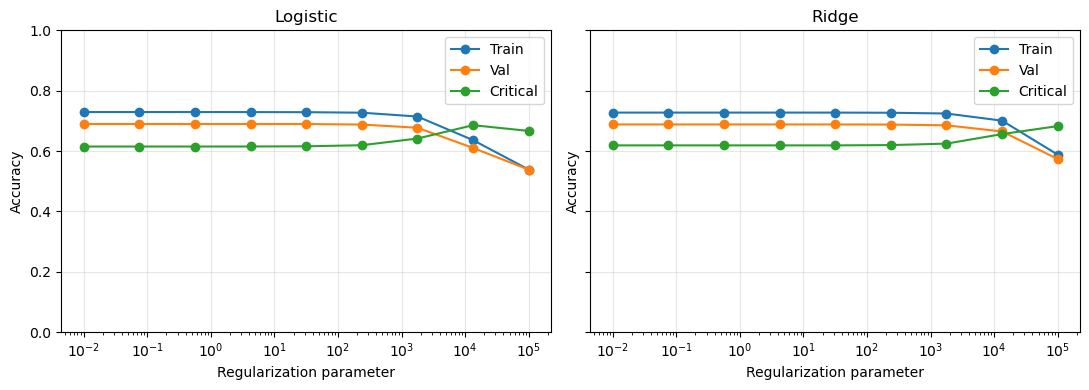

In [25]:
alphas = np.logspace(-2, 5, 9)
results = {model: {split: np.zeros(len(alphas)) for split in ('train', 'val', 'critical')}
           for model in ('logistic', 'ridge')}

for i, alpha in enumerate(tqdm(alphas)):
    logreg = LogisticRegression(C=1.0 / alpha, max_iter=1000)
    ridge = RidgeClassifier(alpha=alpha)
    for name, model in [('logistic', logreg), ('ridge', ridge)]:
        model.fit(X_train, Y_train)
        results[name]['train'][i] = model.score(X_train, Y_train)
        results[name]['val'][i] = model.score(X_val, Y_val)
        results[name]['critical'][i] = model.score(X_critical, Y_critical)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ('logistic', 'ridge')):
    for split in ('train', 'val', 'critical'):
        ax.semilogx(alphas, results[name][split], marker='o', label=split.capitalize())
    ax.set(title=name.capitalize(), xlabel='Regularization parameter', ylabel='Accuracy', ylim=(0, 1))
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

# Extra exercise: Linear Regression (clarifications)

Explore the relation between gradient descent, the Moore–Penrose pseudoinverse, and ridge regularization. Here the squared-error objective is the **summed half-squared error** $\frac12\|Xw-y\|_2^2$.

**Question E.a)** Generate a Gaussian $n\times d$ design matrix with $n=5$, $d=10$ and a random $n$-dimensional target vector.

In [26]:
n, d = 5, 10
X = np.random.randn(n, d)
y = np.random.randn(n)

**Question E.b)** Fit scikit-learn's `LinearRegression` without an intercept.

In [27]:
linear_regression_model = LinearRegression(fit_intercept=False)
linear_regression_model.fit(X, y)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Question E.c)** For $n<d$ and full row rank, the minimum-norm least-squares solution is $w=X^\top(XX^\top)^{-1}y$. Implement this expression and compare the coefficients with scikit-learn's. Why do they agree?

In [28]:
def linear_regression_pi(X, y):
    return X.T @ np.linalg.solve(X @ X.T, y)

w_pi = linear_regression_pi(X, y)
print('sklearn:', linear_regression_model.coef_)
print('Pseudoinverse:', w_pi)

sklearn: [ 0.30249262  0.09485905 -0.2136744   0.24847247 -0.14147042 -0.50824009
  0.15341024 -0.05282995  0.44734855  0.38337607]
Pseudoinverse: [ 0.30249262  0.09485905 -0.2136744   0.24847247 -0.14147042 -0.50824009
  0.15341024 -0.05282995  0.44734855  0.38337607]


**Question E.d)** Implement ridge regression with $\lambda>0$: $w=(X^\top X+\lambda I)^{-1}X^\top y$. Compare with scikit-learn's `Ridge(fit_intercept=False, alpha=1)` using $\lambda=1$.

In [29]:
def linear_regression_ridge(X, y, reg=1.0):
    return np.linalg.solve(X.T @ X + reg * np.eye(X.shape[1]), X.T @ y)

ridge_model = Ridge(fit_intercept=False, alpha=1.0).fit(X, y)
print('sklearn:', ridge_model.coef_)
print('Custom:', linear_regression_ridge(X, y, reg=1.0))

sklearn: [ 0.05264599  0.09053002 -0.10641571  0.13663077 -0.05835138 -0.42443314
  0.09786699 -0.02950935  0.31290129  0.23545511]
Custom: [ 0.05264599  0.09053002 -0.10641571  0.13663077 -0.05835138 -0.42443314
  0.09786699 -0.02950935  0.31290129  0.23545511]


**Question E.e)** Use $\lambda=0.001$ and compare ridge regression to the pseudoinverse solution. What happens as $\lambda\to0^+$?

In [30]:
ridge_small = Ridge(fit_intercept=False, alpha=1e-3).fit(X, y)
print('Pseudoinverse:', w_pi)
print('Ridge:', ridge_small.coef_)

Pseudoinverse: [ 0.30249262  0.09485905 -0.2136744   0.24847247 -0.14147042 -0.50824009
  0.15341024 -0.05282995  0.44734855  0.38337607]
Ridge: [ 0.3019338   0.09486046 -0.21346318  0.24824826 -0.14128105 -0.50810829
  0.15328291 -0.05275514  0.4470946   0.38310497]


**Question E.f)** Compare the training MSE of the pseudoinverse solution and ridge regression at $\lambda=0.1$. Which should be smaller?

In [31]:
ridge_point_one = Ridge(fit_intercept=False, alpha=0.1).fit(X, y)
error_ridge = np.mean((ridge_point_one.predict(X) - y)**2)
error_pi = np.mean((X @ w_pi - y)**2)
print('Ridge MSE:', error_ridge)
print('Pseudoinverse MSE:', error_pi)

Ridge MSE: 0.0009974825569102853
Pseudoinverse MSE: 7.410978426002084e-32


**Question E.g)** Implement one GD step for minimizing $\frac12\|Xw-y\|^2$ and a function returning the **final GD iterate** after `n_iter` steps. The gradient is $X^\top(Xw-y)$.

In [32]:
def gradient_descent_step(X, y, w, eta):
    gradient = X.T @ (X @ w - y)
    return w - eta * gradient

def train(n_iter, X, y, w, eta):
    w = w.copy()
    for _ in range(n_iter):
        w = gradient_descent_step(X, y, w, eta)
    return w

**Question E.h)** Starting from $w_0=0$ and $w_0=\mathbf 1$, run GD for 5000 updates at $\eta=0.01$. Compare the two final vectors with the pseudoinverse result and compare their training errors. What role does initialization play when $n<d$?

In [33]:
w_a = train(5000, X, y, np.zeros(d), 0.01)
w_b = train(5000, X, y, np.ones(d), 0.01)
print('Zero initialization:', w_a)
print('Ones initialization:', w_b)
print('Pseudoinverse:', w_pi)
print('Training MSEs:', np.mean((X @ w_a - y)**2), np.mean((X @ w_b - y)**2))

Zero initialization: [ 0.30249262  0.09485905 -0.2136744   0.24847247 -0.14147042 -0.50824009
  0.15341024 -0.05282995  0.44734855  0.38337607]
Ones initialization: [ 0.45355455  1.61248792  0.39749996  1.35564261  0.41527638  0.00845123
  0.53379183  0.45610554  0.78552935 -0.07453088]
Pseudoinverse: [ 0.30249262  0.09485905 -0.2136744   0.24847247 -0.14147042 -0.50824009
  0.15341024 -0.05282995  0.44734855  0.38337607]
Training MSEs: 5.672402946604838e-30 3.3921018924503506e-30


*Solution note:* Zero-initialized GD converges to $X^+y$. From a general initial vector $w_0$, the limiting solution is $X^+y+(I-X^+X)w_0$: the component in the null space of $X$ is preserved.

**Question E.i)** Now generate a Gaussian matrix with $n=10$ and $d=5$ and a random label vector.

In [34]:
n, d = 10, 5
X = np.random.randn(n, d)
y = np.random.randn(n)

**Question E.j)** Fit `LinearRegression(fit_intercept=False)` to this overdetermined system.

In [35]:
linear_regression_model = LinearRegression(fit_intercept=False).fit(X, y)

**Question E.k)** Assuming $X$ has full column rank, implement the usual OLS expression $w=(X^\top X)^{-1}X^\top y$ and compare to scikit-learn.

In [36]:
def linear_regression_ols(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

w_ols = linear_regression_ols(X, y)
print('Custom OLS:', w_ols)
print('sklearn OLS:', linear_regression_model.coef_)

Custom OLS: [-0.77467038 -0.81407351 -0.28614479 -0.5323383   0.57716495]
sklearn OLS: [-0.77467038 -0.81407351 -0.28614479 -0.5323383   0.57716495]


**Question E.l)** Compare the training MSE of OLS and ridge regression with $\lambda=0.1$. Which should be smaller?

In [37]:
ridge_point_one = Ridge(fit_intercept=False, alpha=0.1).fit(X, y)
error_ridge = np.mean((ridge_point_one.predict(X) - y)**2)
error_ols = np.mean((X @ w_ols - y)**2)
print('Ridge MSE:', error_ridge)
print('OLS MSE:', error_ols)

Ridge MSE: 0.2774464262274442
OLS MSE: 0.2770346499188251


**Question E.m)** Run the GD function defined above from an all-ones initialization and compare the result and training MSE with scikit-learn's OLS solution.

In [38]:
w_gd = train(5000, X, y, np.ones(d), 0.01)
print('OLS weights:', w_ols)
print('GD weights:', w_gd)
print('OLS MSE:', np.mean((X @ w_ols - y)**2))
print('GD MSE:', np.mean((X @ w_gd - y)**2))

OLS weights: [-0.77467038 -0.81407351 -0.28614479 -0.5323383   0.57716495]
GD weights: [-0.77467038 -0.81407351 -0.28614479 -0.5323383   0.57716495]
OLS MSE: 0.2770346499188251
GD MSE: 0.27703464991882515
